# Deep models interpretability
This notebooks shows examples of approaches for interpretation of (pre-)trained model predictions.

In [1]:
import urllib
import skimage
import torch, torch.nn as nn
import torch.nn.functional as F
import torchvision.models

import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

### please, don't remove the following line
x = torch.tensor([1], dtype=torch.float32).to(device)

device: cuda


In [3]:
import requests  # load imagenet class names
response = requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json')
class_labels = {int(key): value for key, (code, value) in response.json().items()}
class_labels[897]

'washer'

### Task I: manual explanation with smoothgrad (2 points)

Let us begin by implementing our own little explainer for [DenseNet121](https://arxiv.org/abs/1608.06993) pretrained on ImageNet.

For the sake of simplicity, we're gonna rely on [SmoothGrad](https://arxiv.org/pdf/1706.03825.pdf) explainer - a simple average of gradients over noisy inputs.

In [ ]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1).train(False).to(device)
# froze weights because only input gradients were needed
model.requires_grad_(False)

# used the same imagenet normalization for predictions and explanations
image_mean = torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]
image_std = torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]

def normalize_images(images):
    return (images - image_mean) / image_std

torch.manual_seed(42)
np.random.seed(42)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


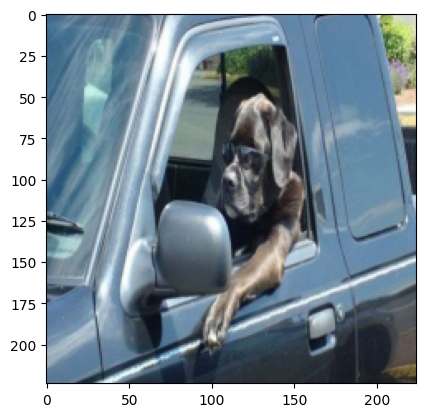

#1: p=0.401	Brabancon_griffon (262)
#2: p=0.115	boxer (242)
#3: p=0.103	chimpanzee (367)
#4: p=0.050	gorilla (366)
#5: p=0.044	pug (254)
#6: p=0.043	howler_monkey (379)
#7: p=0.034	orangutan (365)
#8: p=0.031	Leonberg (255)
#9: p=0.024	bloodhound (163)
#10: p=0.021	cocker_spaniel (219)


In [ ]:
!wget -q https://cdn2.adrianflux.co.uk/wp-fluxposure/uploads/2014/08/no-7.jpg -O img.jpg

image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(normalize_images(image_tensor)), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

Now let's implement SmoothGrad itself.

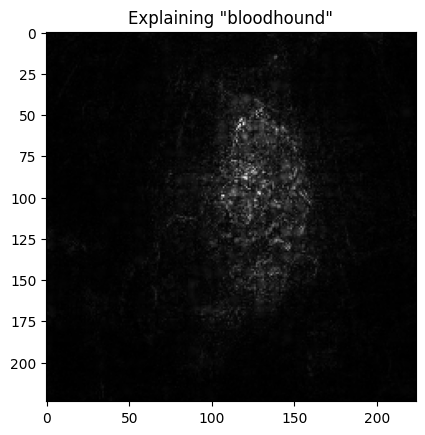

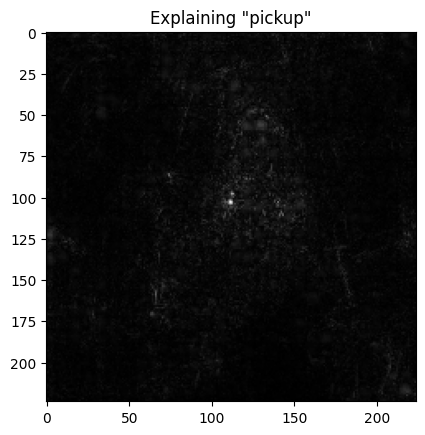

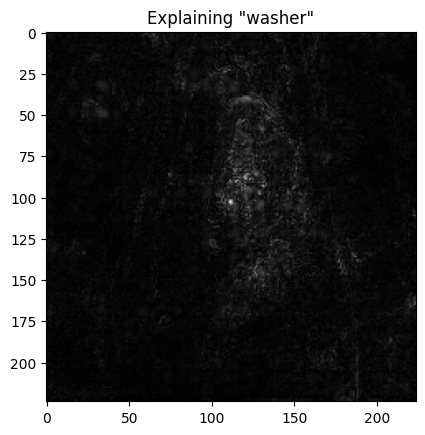

In [6]:
def explain_smoothgrad(image: torch.Tensor, class_ix, num_runs=32, sigma=0.1):
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)  # shape: [1, 3, h, w]

    # 1. create :num_runs: copies of an image
    # 2. apply independent random noise to each copy, use N(0, sigma) distribution
    # 3. compute gradients of logit for class_ix w.r.t. input pixels
    # 4. average these gradients across different images
    # 5. re-shape these gradients in the same shape as original image: (h, w, 3)

    # averaged independent noisy runs without keeping all graphs in memory
    model.eval()
    gradient_sum = torch.zeros_like(image_tensor)
    for _ in range(num_runs):
        noisy_image = (image_tensor + sigma * torch.randn_like(image_tensor)).detach()
        noisy_image.requires_grad_(True)
        logit = model(normalize_images(noisy_image))[0, class_ix]
        gradient = torch.autograd.grad(logit, noisy_image)[0]
        gradient_sum += gradient.detach()

    average_gradients = (gradient_sum / num_runs)[0].permute(1, 2, 0)

    assert tuple(average_gradients.shape) == image.shape
    return abs(average_gradients).cpu().numpy()

for class_ix in 163, 717, 897:  # <-- insert your classes here, use numbers in (brackets)
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    # averaged color channels for a grayscale importance map
    plt.imshow(explain_smoothgrad(image, class_ix).mean(axis=-1), cmap='gray')
    plt.show()

__Let's try it out!__ Peter Higgs nobel prize photo

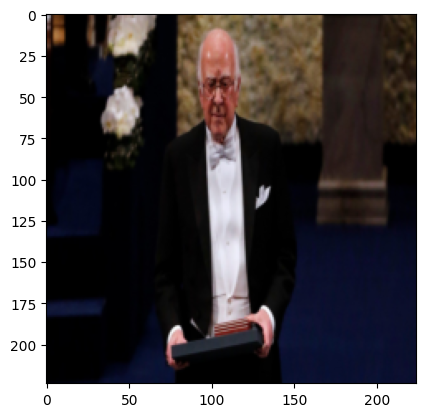

#1: p=0.283	suit (834)
#2: p=0.133	bow_tie (457)
#3: p=0.039	Windsor_tie (906)
#4: p=0.032	groom (982)
#5: p=0.031	vestment (887)
#6: p=0.025	harmonica (593)
#7: p=0.025	Loafer (630)
#8: p=0.024	grand_piano (579)
#9: p=0.021	throne (857)
#10: p=0.020	academic_gown (400)


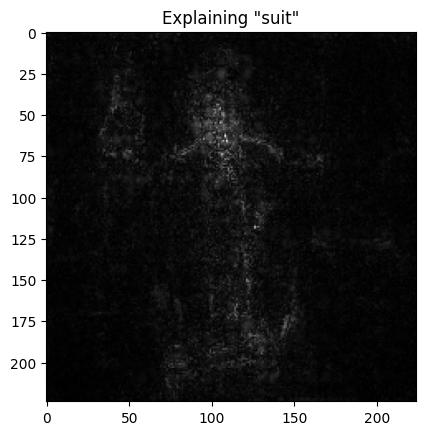

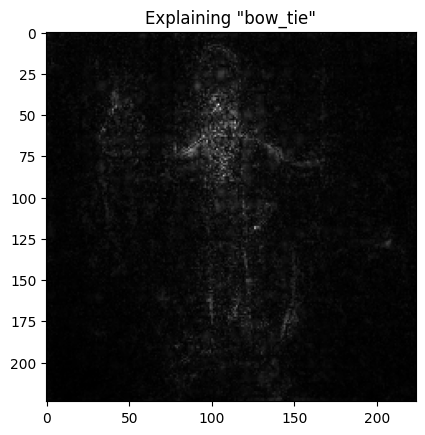

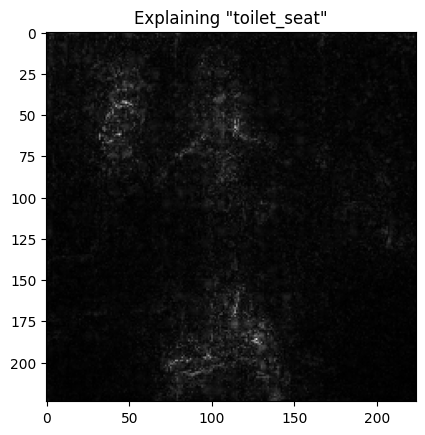

In [7]:
!wget -q https://i.pinimg.com/originals/3a/e1/83/3ae18369ab2e86be83e637ad702ec832.jpg -O img.jpg

image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(normalize_images(image_tensor)), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

for class_ix in 834, 457, 861:
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    # averaged color channels for a grayscale importance map
    plt.imshow(explain_smoothgrad(image, class_ix).mean(axis=-1), cmap='gray')
    plt.show()

### SHapley Additive exPlanations
Now, let's try something heavier. The current state of the art in explaining model predictions is [SHAP](https://arxiv.org/abs/1705.07874): Shapley Additive Explanations.

This method is based on [Shapley values](https://en.wikipedia.org/wiki/Shapley_value) - a game-theoretic concept that evaluates the contribution of individual players in a cooperative game. Except this time our "players" are input features and the "game" is predicting whichever output the model gave.

Computing Shapley values naively requires $O(F!)$ time where F is the number of features. To make this computation more feasible, authors [proposed](https://arxiv.org/abs/1705.07874) several approximations, one of which relies on averaged gradients. This approximation also requires "background" data - other images similar to the ones in question that can be used as reference points.

In [8]:
import shap
# load "background" images - some 50 random images from ImageNet used as "other data points" for SHAP
imagenet_images, _ = shap.datasets.imagenet50()
background = imagenet_images
background = torch.as_tensor(background / 255.0, device=device, dtype=torch.float32)
background = background.permute(0, 3, 1, 2)
background = normalize_images(background)
background.size()

torch.Size([50, 3, 224, 224])

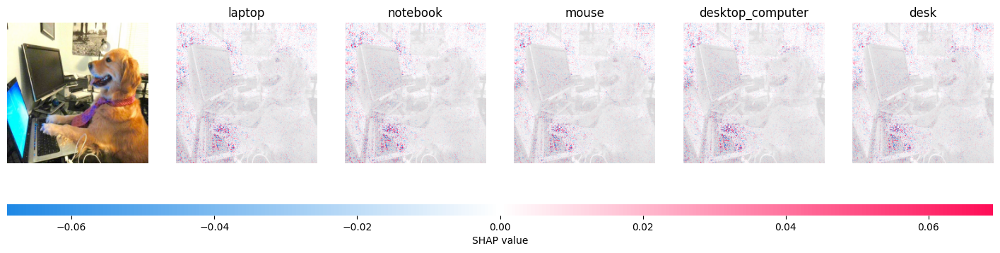

In [9]:
shap.initjs()  # run it before every (interactive) shap visualizer in colab
# v-- image to explain. If you're not using a GPU, this may take up to 20 minutes.
!wget -q https://i.pinimg.com/originals/32/da/5c/32da5c3314fcc5ebf1a7b7d1548fcb03.jpg -O img.jpg
image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)
explainer = shap.GradientExplainer((model, model.conv1), background)
shap_values, indices = explainer.shap_values(normalize_images(image_tensor), ranked_outputs=5, nsamples=200)
# handled both older list outputs and newer shap arrays
if isinstance(shap_values, list):
    shap_values = np.stack(shap_values, axis=-1)
shap.image_plot(shap_values=list(np.transpose(shap_values, (4, 0, 2, 3, 1))),
                pixel_values=image_tensor.permute(0, 2, 3, 1).cpu().numpy(),
                labels=np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy()))

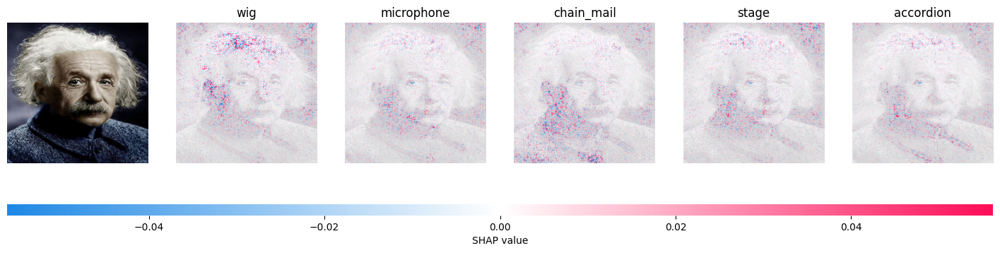

In [10]:
shap.initjs() # obligatory physicist reference
!wget -q https://images-na.ssl-images-amazon.com/images/I/51ArQaCkkZL._AC_.jpg -O img.jpg
image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)
explainer = shap.GradientExplainer((model, model.conv1), background)
shap_values, indices = explainer.shap_values(normalize_images(image_tensor), ranked_outputs=5, nsamples=200)
# handled both older list outputs and newer shap arrays
if isinstance(shap_values, list):
    shap_values = np.stack(shap_values, axis=-1)
shap.image_plot(shap_values=list(np.transpose(shap_values, (4, 0, 2, 3, 1))),
                pixel_values=image_tensor.permute(0, 2, 3, 1).cpu().numpy(),
                labels=np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy()))

###### Explaining classical machine learning models

Finally, let's see how SHAP explainers can be applied to more conventional machine learning models like gradient boosting.

Spoiler: exactly the same from a user's perspective. However, this time we're gonna use a different Shapley approximation implemented in TreeExplainer. For a full set of available explainers, take a look at their official [examples page](https://github.com/slundberg/shap/tree/master/notebooks).

**NB: the following cells requires JavaScript support and should work in Jupyter (not JupyterLab or cocalc)**.
In that case try running it on Google colab: https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb

In [11]:
import catboost # pip install catboost
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target.values
ensemble = catboost.CatBoostRegressor(iterations=100, learning_rate=0.1)
ensemble.fit(X, y, verbose=False, plot=False)
explainer = shap.TreeExplainer(ensemble)
shap_values = explainer.shap_values(X)

shap.initjs() # visualize explanation of the first example
shap.force_plot(explainer.expected_value, shap_values[0, :], X.iloc[0, :])

In [12]:
# Explain training data: each *column* is a rotated plot from above, stacked for all training samples
shap.initjs() # (this plot is interactive, hover mouse to see feature names)
shap.force_plot(explainer.expected_value, shap_values[::100], X[::100])

### Task II: Explain Intermediate Layers of Resnet50 on ImageNet (3 points)

Sometimes, computing explanations w.r.t. pixels is more difficult (and less interpretable) than using intermediate layers that are closer to the "output" layer. The trick is to compute low-resolution explanations of output w.r.t. intermediate layer and then resizing them to fit the original image.

Each layer in deep CNN learns filters of increasing complexity. The first layers learn basic feature detection filters such as edges and corners. The middle layers learn filters that detect parts of objects — for faces, they might learn to respond to features like eyes and brows, and deeper layers capture entire objects.

**Your task** is to explain ResNet50 model outputs with respect to the convolution module from 1st, 2nd, 3rd and 4th layer of the pretrained Resnet50 network using the same GradientExplainer. *The task may require some googling or browsing the [docs](https://shap.readthedocs.io/en/latest) :)* A good starting point is from [this example](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Explain%20an%20Intermediate%20Layer%20of%20VGG16%20on%20ImageNet%20%28PyTorch%29.html), but for ResNet50 and on different images.

**Please use at least 10 images from across the internet (or from ImageNet) and compare the 2nd and 4th layer explanations on these images.**


### intermediate-layer comparison setup

Used the first 10 images from `shap.datasets.imagenet50()` and the remaining 40 as a separate background. This collection contains internet-sourced replacements for ImageNet images, so its labels were not treated as ground truth. Explained each image's top predicted class, not classification accuracy.

Selected `conv3` in the last bottleneck of each ResNet50 stage. `GradientExplainer((model, layer), ...)` explained the **input** of that convolution, not its output. These feature maps had spatial sizes 56×56, 28×28, 14×14 and 7×7. Kept 200 SHAP samples per explanation, as in the examples above; the complete calculation may take a long time on CPU.


In [13]:
# separated the explained images from the background images
comparison_images = imagenet_images[:10].astype(np.float32) / 255.0
comparison_tensor = torch.as_tensor(comparison_images, device=device).permute(0, 3, 1, 2)
comparison_tensor = normalize_images(comparison_tensor)
comparison_background = background[10:]
assert len(comparison_images) == 10
assert len(comparison_background) == 40

layers = {
    'layer1': model.layer1[-1].conv3,
    'layer2': model.layer2[-1].conv3,
    'layer3': model.layer3[-1].conv3,
    'layer4': model.layer4[-1].conv3,
}

model.eval()
with torch.no_grad():
    comparison_probs = model(comparison_tensor).softmax(dim=1)
    comparison_classes = comparison_probs.argmax(dim=1).cpu().numpy()

for i, class_ix in enumerate(comparison_classes):
    print(f'image {i + 1}: {class_labels[int(class_ix)]}, '
          f'probability = {comparison_probs[i, class_ix].item():.2%}')


image 1: streetcar, probability = 14.99%
image 2: American_egret, probability = 93.61%
image 3: speedboat, probability = 99.24%
image 4: puck, probability = 99.93%
image 5: agama, probability = 71.59%
image 6: forklift, probability = 17.48%
image 7: pot, probability = 50.47%
image 8: sombrero, probability = 76.34%
image 9: studio_couch, probability = 76.79%
image 10: promontory, probability = 63.05%


In [ ]:
layer_maps = {}
layer_shapes = {}
for layer_name, layer in layers.items():
    layer_explainer = shap.GradientExplainer(
        (model, layer), comparison_background, batch_size=8
    )
    layer_maps[layer_name] = []
    for i in range(len(comparison_images)):
        values, indices = layer_explainer.shap_values(
            comparison_tensor[i:i + 1], ranked_outputs=1, nsamples=200, rseed=42 + i
        )
        assert indices[0, 0].item() == comparison_classes[i]
        if isinstance(values, list):
            values = np.stack(values, axis=-1)
        assert values.ndim == 5 and values.shape[0] == values.shape[-1] == 1
        assert np.isfinite(values).all()
        layer_shapes[layer_name] = values.shape[2:4]

        # summed signed channel contributions before resizing the map
        small_map = values[0, :, :, :, 0].sum(axis=0)
        heatmap = resize(small_map, comparison_images.shape[1:3],
                         order=1, preserve_range=True, anti_aliasing=False)
        layer_maps[layer_name].append(heatmap)
        print(f'{layer_name}: image {i + 1}/10, feature map = {small_map.shape}', flush=True)
    layer_maps[layer_name] = np.stack(layer_maps[layer_name])
    del layer_explainer


layer1: image 1/10, feature map = (56, 56)
layer1: image 2/10, feature map = (56, 56)
layer1: image 3/10, feature map = (56, 56)
layer1: image 4/10, feature map = (56, 56)
layer1: image 5/10, feature map = (56, 56)
layer1: image 6/10, feature map = (56, 56)
layer1: image 7/10, feature map = (56, 56)
layer1: image 8/10, feature map = (56, 56)
layer1: image 9/10, feature map = (56, 56)
layer1: image 10/10, feature map = (56, 56)
layer2: image 1/10, feature map = (28, 28)
layer2: image 2/10, feature map = (28, 28)
layer2: image 3/10, feature map = (28, 28)
layer2: image 4/10, feature map = (28, 28)
layer2: image 5/10, feature map = (28, 28)
layer2: image 6/10, feature map = (28, 28)
layer2: image 7/10, feature map = (28, 28)
layer2: image 8/10, feature map = (28, 28)
layer2: image 9/10, feature map = (28, 28)
layer2: image 10/10, feature map = (28, 28)
layer3: image 1/10, feature map = (14, 14)
layer3: image 2/10, feature map = (14, 14)
layer3: image 3/10, feature map = (14, 14)
layer3: i

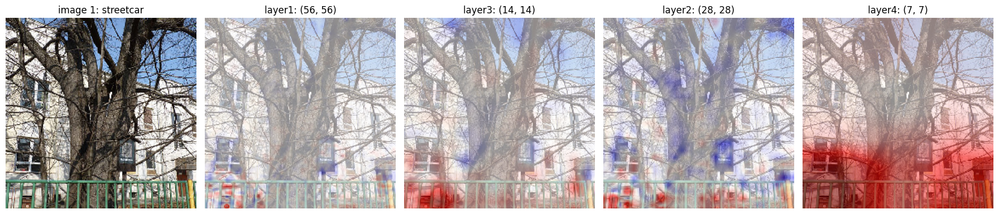

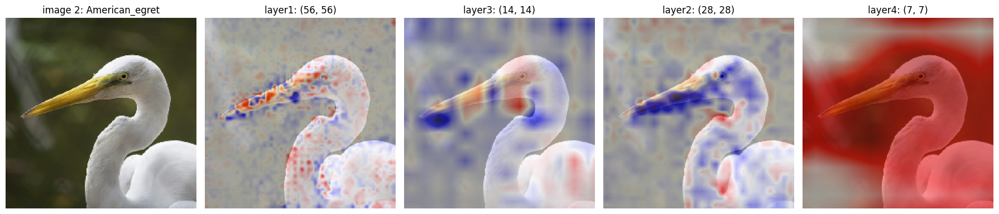

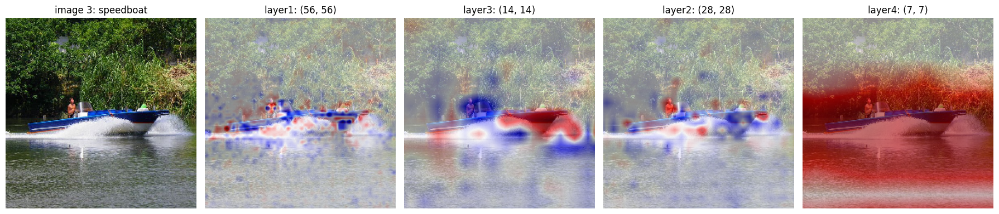

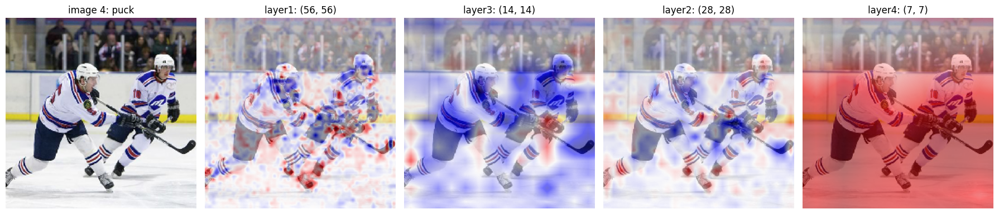

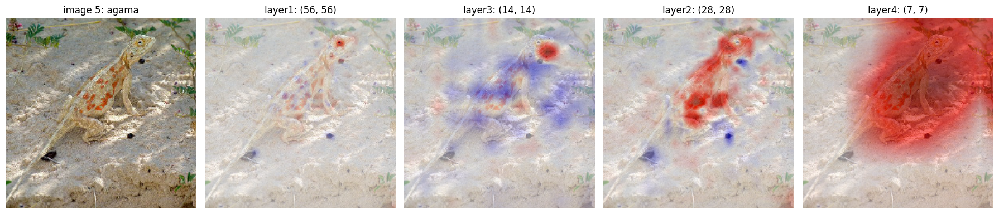

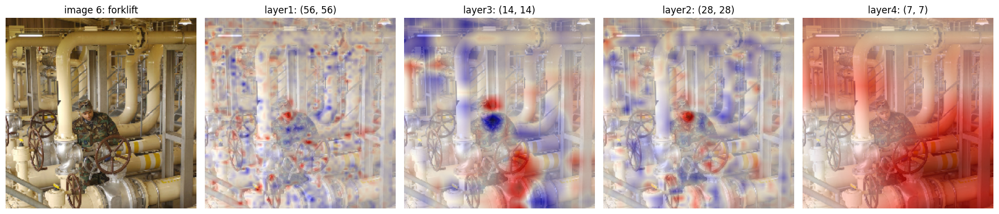

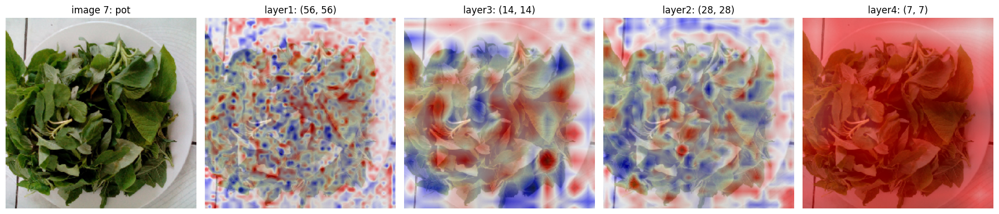

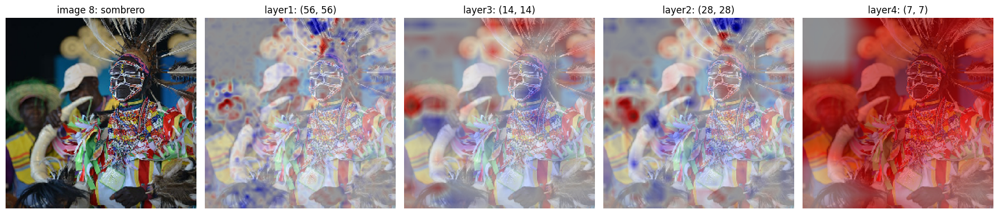

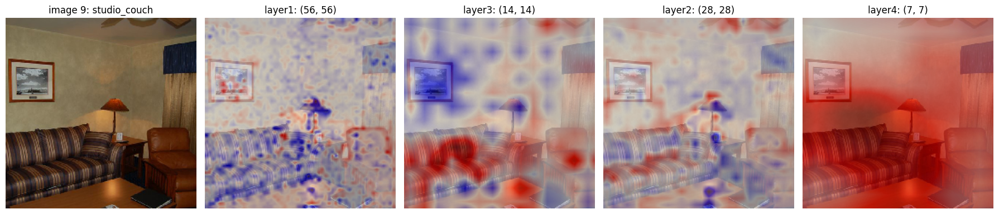

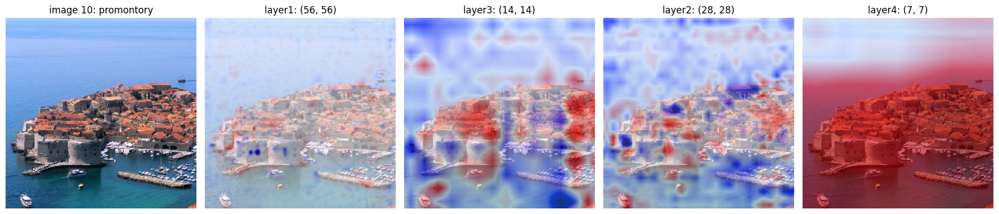

In [ ]:
display_order = ['layer1', 'layer3', 'layer2', 'layer4']
for i, image in enumerate(comparison_images):
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(image)
    axes[0].set_title(f'image {i + 1}: {class_labels[int(comparison_classes[i])]}')
    for ax, layer_name in zip(axes[1:], display_order):
        heatmap = layer_maps[layer_name][i]
        scale = max(float(np.abs(heatmap).max()), 1e-12)
        ax.imshow(image)
        ax.imshow(heatmap / scale, cmap='seismic', vmin=-1, vmax=1, alpha=0.55)
        ax.set_title(f'{layer_name}: {layer_shapes[layer_name]}')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### comparison of layer2 and layer4

Red showed positive and blue negative contributions to the selected class logit. Each map was scaled separately for display, so color strength should not be compared as an absolute contribution across layers. Resizing aligned the feature grids with the image for visualization; it did not turn intermediate-feature attributions into exact pixel attributions.

The following comparison measured overlap between the strongest 20% of locations by absolute attribution in layer2 and layer4. It was a spatial agreement measure, not an explanation-quality score or model accuracy. The feature-grid sizes and highlighted image regions should also be considered when interpreting this number.


In [16]:
# compared the strongest spatial regions for each image
region_overlaps = []
for i in range(len(comparison_images)):
    masks = []
    for layer_name in ['layer2', 'layer4']:
        importance = np.abs(layer_maps[layer_name][i]).ravel()
        assert importance.max() > 0, 'the explanation map was all zeros'
        strongest = np.argsort(importance, kind='stable')[-int(0.2 * importance.size):]
        mask = np.zeros(importance.size, dtype=bool)
        mask[strongest] = True
        masks.append(mask)
    overlap = np.logical_and(*masks).sum() / np.logical_or(*masks).sum()
    region_overlaps.append(overlap)
    print(f'image {i + 1}, {class_labels[int(comparison_classes[i])]}: '
          f'layer2 / layer4 region overlap = {overlap:.2%}')
print(f'mean region overlap = {np.mean(region_overlaps):.2%}')


image 1, streetcar: layer2 / layer4 region overlap = 22.24%
image 2, American_egret: layer2 / layer4 region overlap = 31.70%
image 3, speedboat: layer2 / layer4 region overlap = 30.52%
image 4, puck: layer2 / layer4 region overlap = 15.59%
image 5, agama: layer2 / layer4 region overlap = 48.63%
image 6, forklift: layer2 / layer4 region overlap = 7.93%
image 7, pot: layer2 / layer4 region overlap = 12.19%
image 8, sombrero: layer2 / layer4 region overlap = 19.27%
image 9, studio_couch: layer2 / layer4 region overlap = 19.86%
image 10, promontory: layer2 / layer4 region overlap = 20.35%
mean region overlap = 22.83%


## layer2 and layer4 comparison
I compared the explanations on 10 images. Layer2 showed more local details, while layer4 produced broader, smoother regions, partly because its feature grid was smaller (7×7 versus 28×28). For the egret, layer2 highlighted parts of the beak, head and neck, while layer4 covered the bird and some background. For the lizard, layer2 highlighted individual body parts, while layer4 covered a larger region around the animal.

The mean overlap between the strongest 20% of regions was 22.83%, ranging from 7.93% for image 6 to 48.63% for the lizard. This measured spatial agreement, not explanation quality. Image 6 showed a person among pipes, but the model predicted forklift with only 17.48% probability, showing that an explanation does not make a prediction correct.

## References

* SHAP explainer based on superpixels - [notebook](https://slundberg.github.io/shap/notebooks/ImageNet%20VGG16%20Model%20with%20Keras.html)
* SHAP reference notebook - [view on github](https://github.com/slundberg/shap/tree/master/notebooks)
* More various explainers in [ELI5](https://github.com/TeamHG-Memex/eli5)
* Same notebook on Google [Colab](https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb)